# Box Q-MDF features - direct Q prediction

This notebook trains a head that predicts the Q-MDF distance field `Q` directly. The medial field used by DMF-style losses and visualizations is reconstructed as `M = Q + |SDF|`.


## Imports and Device


In [1]:

import copy
import importlib
import json
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as data
import trimesh
import trimesh.transformations as trafo
from tqdm import tqdm

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'source').is_dir():
    raise RuntimeError('Run this notebook from the points2surf repo root.')
sys.path.insert(0, str(REPO_ROOT))

from source import data_loader, medial_field, points_to_surf_medial, sdf
from source.base import point_cloud
from source.base.utils import torch_load

importlib.reload(points_to_surf_medial)
importlib.reload(medial_field)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)



Device: cuda:0


## Experiment Configuration


In [2]:

SHAPE_NAME = 'box'
SHAPE_OBJ = REPO_ROOT / 'data' / 'box.obj'
DATASET_DIR = REPO_ROOT / 'datasets' / 'box_medial'
OUT_DIR = REPO_ROOT / 'models' / 'box_q_mdf_features'

MODEL_DIR = REPO_ROOT / 'models'
MODEL_NAME = 'p2s_vanilla'
MODEL_FILE = MODEL_DIR / f'{MODEL_NAME}_model_149.pth'
PARAM_FILE = MODEL_DIR / f'{MODEL_NAME}_params.pth'

NUM_QUERY_PTS = 4000
NUM_POINTS = 50000
TRAIN_QUERY_LIMIT = None      # set e.g. 512 for a quick CPU experiment
NEAR_SURFACE_QUERY_RATIO = 0.25
FAR_QUERY_PTS_RATIO = 0.35
MIN_INSIDE_SDF_FOR_MEDIAL_TRAIN = 0.03  # avoid near-surface M=0 collapse in medial training
SDF_GRADIENT_MIN_FACE_GAP = 0.18  # ignore box SDF tie/medial bands where the GT gradient is ambiguous
RESAMPLE_GT_QUERIES_EVERY_BATCH = True
GT_QUERY_RESAMPLE_CANDIDATE_MULT = 2
BATCH_SIZE = 170
NEPOCH = 100
LR = 1e-3

ORTHOGONALITY_WARMSTART_STEPS = 1500
ORTHOGONALITY_WARMSTART_LR = 1e-3
ORTHOGONALITY_WARMSTART_WEIGHT = 20.0
ORTHOGONALITY_WARMSTART_METRIC_EVERY = 0
ORTHOGONALITY_REFINE_LBFGS_STEPS = 80
ORTHOGONALITY_REFINE_LBFGS_LR = 0.5
ORTHOGONALITY_REFINE_BATCH_SIZE = 170
ORTHOGONALITY_REFINE_ROUNDS = 3
ORTHOGONALITY_TARGET_NORMAL_RMS = 0.10

RUN_GT_SDF_OVERFIT_DEBUG = False
USE_QUERY_COORDS_FOR_MEDIAL = True
MEDIAL_HIDDEN_MULT = 4.0
DETACH_BACKBONE_FOR_Q_GRAD = True  # make grad Q come from query coordinates, not frozen SDF features
USE_QUERY_RESIDUAL_Q_HEAD = True    # extra coordinate branch for the Q-gradient objective
QUERY_RESIDUAL_ENCODING = 'fourier'
QUERY_FOURIER_NUM_FREQS = 2
GT_SDF_OVERFIT_STEPS = 120
GT_SDF_OVERFIT_LR = 1e-3
GT_SDF_OVERFIT_WARMSTART_MODEL = True

SLICE_GRID_RES = 96
VIS_SLICE_GRID_RES = 64
USE_SDF_SCALE_FOR_MF_VIS = False
SLICE_EPSILON = 16
USE_GT_SDF = True  # if True, every medial-training SDF use comes from the GT mesh SDF
INFER_BATCH = 170
EVAL_QUERY_LIMIT = 2000       # set e.g. 2000 if grid evaluation is too slow
MAX_MEDIAL_POINTS = 30000
GT_MEDIAL_AXIS_SURFACE_SAMPLES = 3000
GT_MEDIAL_AXIS_SLICE_WIDTH_CELLS = 2.5
Q_MDF_LEVEL_EPSILON = 0.01
ORTHOGONALITY_METRIC_QUERY_PTS = 1500
ORTHOGONALITY_METRIC_EVERY = 1
GT_AXIS_FIELD_METRIC_POINTS = 512
USE_BEST_GT_AXIS_FIELD_HEAD_FOR_VIS = False
USE_BEST_ORTHOGONALITY_HEAD_FOR_VIS = True
PREDICT_Q_MDF = True  # head predicts Q; losses reconstruct M = Q + |phi|
USE_SDF_GRADIENT_HEAD = True  # auxiliary head predicts the GT SDF gradient vector

DIAGNOSTIC_EVERY = 0        # old opposing-normal diagnostic; new GT-axis metrics run via ORTHOGONALITY_METRIC_EVERY
DIAGNOSTIC_QUERY_PTS = 512
GT_DIAGNOSTIC_SAMPLE_COUNT = 7000

LOSS_WEIGHTS = medial_field.get_default_weights()

LOSS_WEIGHTS['sdf_gradient'] = 0.0      # auxiliary supervision for predicted SDF gradient direction
LOSS_WEIGHTS['maximality'] = 0.0        # automatically satisfied by M = Q + |SDF|
LOSS_WEIGHTS['inscription'] = 1       # disabled while making Q-gradient losses converge
LOSS_WEIGHTS['orthogonality'] = 20.0    # Q-MDF direction: grad Q dot SDF normal matches the inside target
LOSS_WEIGHTS['q_eikonal'] = 10.0        # encourage ||grad Q|| ~= 1

LOSS_WEIGHTS['eikonal'] = 1.0
LOSS_WEIGHTS['surface_reg'] = 1.0

if USE_GT_SDF:
    LOSS_WEIGHTS['eikonal'] = 0.0
    LOSS_WEIGHTS['surface_reg'] = 0.0

OUT_DIR.mkdir(parents=True, exist_ok=True)




## Dataset and Query Preparation


In [3]:

def to_unit_cube(mesh):
    mesh = mesh.copy()
    center = (mesh.bounds[0] + mesh.bounds[1]) * 0.5
    mesh.apply_transform(trafo.translation_matrix(-center))
    mesh.apply_transform(trafo.scale_matrix(1.0 / mesh.extents.max()))
    return mesh

mesh_gt = to_unit_cube(trimesh.load(SHAPE_OBJ, force='mesh'))
USE_ANALYTIC_BOX_SDF = USE_GT_SDF and SHAPE_NAME == 'box'
BOX_BOUNDS = mesh_gt.bounds.astype(np.float32) if USE_ANALYTIC_BOX_SDF else None

def sample_gt_sdf(query_ms):
    if USE_ANALYTIC_BOX_SDF:
        query_t = torch.as_tensor(query_ms, dtype=torch.float32, device=device)
        phi_t, _ = medial_field.box_sdf_and_gradient(BOX_BOUNDS, query_t, device=device)
        return phi_t.detach().cpu().numpy().astype(np.float32)
    return -sdf.get_signed_distance(mesh_gt, query_ms).astype(np.float32)

def gt_sdf_sampler_torch(query_t):
    if USE_ANALYTIC_BOX_SDF:
        return medial_field.box_sdf_and_gradient(BOX_BOUNDS, query_t, device=query_t.device)
    return medial_field.gt_sdf_and_gradient(mesh_gt, query_t, device=query_t.device)

def gt_sdf_valid_mask_torch(query_t):
    if USE_ANALYTIC_BOX_SDF and SDF_GRADIENT_MIN_FACE_GAP > 0.0:
        return medial_field.box_sdf_gradient_valid_mask(
            BOX_BOUNDS, query_t, min_face_gap=SDF_GRADIENT_MIN_FACE_GAP, device=query_t.device)
    return torch.ones(query_t.shape[0], dtype=torch.bool, device=query_t.device)

if SHAPE_NAME == 'box':
    pts, _ = trimesh.sample.sample_surface(mesh_gt, NUM_POINTS)
    pts = pts.astype(np.float32)
    print(f'Sampled {pts.shape[0]:,} surface points from box mesh.')
else:
    pts = mesh_gt.vertices[:, :3].astype(np.float32)
    if pts.shape[0] > NUM_POINTS:
        pts = pts[np.random.default_rng(42).choice(pts.shape[0], NUM_POINTS, replace=False)]

pts_dir = DATASET_DIR / '04_pts'
qpts_dir = DATASET_DIR / '05_query_pts'
qdist_dir = DATASET_DIR / '05_query_dist'
for d in (pts_dir, qpts_dir, qdist_dir):
    d.mkdir(parents=True, exist_ok=True)
np.save(pts_dir / f'{SHAPE_NAME}.xyz.npy', pts)
(DATASET_DIR / 'testset.txt').write_text(f'{SHAPE_NAME}')

query_pts = medial_field.make_medial_training_queries(
    mesh_gt, NUM_QUERY_PTS,
    near_surface_ratio=NEAR_SURFACE_QUERY_RATIO,
    far_query_pts_ratio=FAR_QUERY_PTS_RATIO,
    seed=42)
if USE_GT_SDF:
    query_phi_gt = sample_gt_sdf(query_pts)
    inside_query_mask = query_phi_gt < -MIN_INSIDE_SDF_FOR_MEDIAL_TRAIN
    if not np.any(inside_query_mask):
        inside_query_mask = query_phi_gt < -1e-5
        if not np.any(inside_query_mask):
            raise RuntimeError('USE_GT_SDF is on, but no inside training queries were sampled.')
        print(
            'MIN_INSIDE_SDF_FOR_MEDIAL_TRAIN removed every query; '
            'falling back to any inside query.')
    print(
        f'USE_GT_SDF: keeping {inside_query_mask.sum():,}/{len(query_pts):,} inside training queries '
        f'with phi < {-MIN_INSIDE_SDF_FOR_MEDIAL_TRAIN:.4f}')
    query_pts = query_pts[inside_query_mask]
query_sdf_placeholder = np.zeros(len(query_pts), dtype=np.float32)

np.save(qpts_dir / f'{SHAPE_NAME}.ply.npy', query_pts.astype(np.float32))
np.save(qdist_dir / f'{SHAPE_NAME}.ply.npy', query_sdf_placeholder)
print(f'Prepared {len(query_pts)} mixed query points. Placeholder distances are not used by DMF losses.')






Sampled 50,000 surface points from box mesh.
USE_GT_SDF: keeping 1,064/4,000 inside training queries with phi < -0.0300
Prepared 1064 mixed query points. Placeholder distances are not used by DMF losses.


## Backbone, Q Head, and Batch Helpers


In [4]:

backbone, train_opt = points_to_surf_medial.load_pretrained_backbone(
    str(MODEL_FILE), str(PARAM_FILE), device)
print('Backbone outputs:', train_opt.outputs)

if USE_GT_SDF:
    base_ds = None
    train_ds = None
    loader = None
    print('USE_GT_SDF: skipping PointcloudPatchDataset; using direct GT batches.')
else:
    base_ds = data_loader.PointcloudPatchDataset(
        root=str(DATASET_DIR),
        shape_list_filename='testset.txt',
        points_per_patch=train_opt.points_per_patch,
        patch_radius=train_opt.patch_radius,
        patch_features=train_opt.outputs,
        seed=42,
        center=train_opt.patch_center,
        cache_capacity=1,
        pre_processed_patches=True,
        sub_sample_size=train_opt.sub_sample_size,
        reconstruction=False,
        epsilon=-1,
        uniform_subsample=getattr(train_opt, 'uniform_subsample', 0),
        fixed_subsample=getattr(train_opt, 'fixed_subsample', 0),
        num_workers=0,
    )
    train_ds = base_ds
    if TRAIN_QUERY_LIMIT is not None:
        train_ds = data.Subset(base_ds, np.arange(min(TRAIN_QUERY_LIMIT, len(base_ds))))
    loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = points_to_surf_medial.PointsToSurfMedialModel(
    backbone,
    hidden_mult=MEDIAL_HIDDEN_MULT,
    use_query_coords=USE_QUERY_COORDS_FOR_MEDIAL,
    detach_backbone_for_medial_grad=DETACH_BACKBONE_FOR_Q_GRAD,
    use_query_residual_head=USE_QUERY_RESIDUAL_Q_HEAD,
    query_residual_encoding=QUERY_RESIDUAL_ENCODING,
    query_fourier_num_freqs=QUERY_FOURIER_NUM_FREQS).to(device)
if PREDICT_Q_MDF:
    medial_field.bind_q_mdf_model(model)
    print('Q-MDF mode: medial_head predicts Q; M is reconstructed as Q + |phi| for auxiliary losses.')
if USE_SDF_GRADIENT_HEAD:
    medial_field.attach_sdf_gradient_head(model)
    print('SDF-gradient mode: auxiliary head predicts the GT SDF gradient vector.')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Trainable params: {trainable:,} | frozen backbone params: {frozen:,}')




# Direct GT-SDF batches avoid stale preprocessed patch indices and work for tiny meshes like the box.
direct_gt_rng = np.random.RandomState(4242)
direct_gt_patch_rng = np.random.RandomState(0)
direct_gt_global_rng = np.random.RandomState(1)
direct_gt_kdtree = None
if USE_GT_SDF:
    import scipy.spatial as spatial
    direct_gt_kdtree = spatial.cKDTree(pts)

def sample_fresh_inside_gt_queries(batch_size):
    selected = []
    attempts = 0
    while sum(arr.shape[0] for arr in selected) < batch_size and attempts < 20:
        attempts += 1
        candidate_count = max(batch_size * GT_QUERY_RESAMPLE_CANDIDATE_MULT, batch_size)
        candidates = medial_field.make_medial_training_queries(
            mesh_gt, candidate_count,
            near_surface_ratio=NEAR_SURFACE_QUERY_RATIO,
            far_query_pts_ratio=FAR_QUERY_PTS_RATIO,
            seed=int(direct_gt_rng.randint(0, 2**31 - 1)))
        phi = sample_gt_sdf(candidates)
        mask = phi < -MIN_INSIDE_SDF_FOR_MEDIAL_TRAIN
        if not np.any(mask):
            mask = phi < -1e-5
        if np.any(mask):
            selected.append(candidates[mask].astype(np.float32))
    if selected:
        queries = np.concatenate(selected, axis=0)
        if queries.shape[0] >= batch_size:
            ids = direct_gt_rng.choice(queries.shape[0], batch_size, replace=False)
            return queries[ids].astype(np.float32)
    replace = len(query_pts) < batch_size
    ids = direct_gt_rng.choice(len(query_pts), batch_size, replace=replace)
    return query_pts[ids].astype(np.float32)

def make_direct_gt_batch(batch_size=BATCH_SIZE):
    if RESAMPLE_GT_QUERIES_EVERY_BATCH:
        batch_queries = sample_fresh_inside_gt_queries(batch_size)
    else:
        replace = len(query_pts) < batch_size
        ids = direct_gt_rng.choice(len(query_pts), batch_size, replace=replace)
        batch_queries = query_pts[ids].astype(np.float32)
    return medial_field._make_query_batch(
        batch_queries, pts, direct_gt_kdtree, train_opt,
        direct_gt_patch_rng, direct_gt_global_rng, device)




Backbone outputs: ['imp_surf_magnitude', 'imp_surf_sign', 'patch_pts_ids', 'p_index']
USE_GT_SDF: skipping PointcloudPatchDataset; using direct GT batches.
Q-MDF mode: medial_head predicts Q; M is reconstructed as Q + |phi| for auxiliary losses.
SDF-gradient mode: auxiliary head predicts the GT SDF gradient vector.
Trainable params: 348,236 | frozen backbone params: 6,167,814


## GT Axis for Evaluation


In [5]:
# Build the approximate medial axis for evaluation only; it is not used as a Q-MDF loss target.
if 'gt_medial_axis_pts' not in globals() or 'gt_medial_axis_radii' not in globals():
    if SHAPE_NAME == 'box':
        print('Computing sampled analytic GT medial-axis approximation for box...')
        gt_medial_axis_pts, gt_medial_axis_radii = medial_field.approximate_box_medial_axis_from_bounds(
            mesh_gt.bounds, grid_resolution=max(32, SLICE_GRID_RES),
            max_points=MAX_MEDIAL_POINTS, seed=123)
        gt_axis_file = OUT_DIR / 'gt_medial_axis_box.ply'
        gt_axis_source = 'box bounds tie-set'
    else:
        print('Computing Voronoi GT medial-axis approximation...')
        gt_medial_axis_pts, gt_medial_axis_radii = medial_field.approximate_medial_axis_voronoi_from_mesh(
            mesh_gt, surface_sample_count=GT_MEDIAL_AXIS_SURFACE_SAMPLES,
            max_points=MAX_MEDIAL_POINTS, seed=123)
        gt_axis_file = OUT_DIR / 'gt_medial_axis_voronoi.ply'
        gt_axis_source = 'surface-sample Voronoi'
    point_cloud.write_ply(str(gt_axis_file), gt_medial_axis_pts)
else:
    gt_axis_source = 'existing notebook variables'

print(f'GT medial-axis points ({gt_axis_source}): {gt_medial_axis_pts.shape[0]:,}')


Computing sampled analytic GT medial-axis approximation for box...
GT medial-axis points (box bounds tie-set): 26,320


## Gradient Smoke Test


In [6]:
# GT-SDF medial-loss gradient smoke test
if USE_GT_SDF:
    smoke_batch = make_direct_gt_batch()
    for k in smoke_batch:
        smoke_batch[k] = smoke_batch[k].to(device)
    model.train()
    smoke_loss, smoke_parts = medial_field.compute_q_mdf_losses_gt_sdf(
        model, smoke_batch, train_opt, mesh_gt, weights=LOSS_WEIGHTS,
        sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
    model.zero_grad(set_to_none=True)
    smoke_loss.backward()
    smoke_q_grad_norm = 0.0
    for p in model.medial_head.parameters():
        if p.grad is not None:
            smoke_q_grad_norm += float(p.grad.detach().norm().cpu())
    smoke_sdf_grad_norm = 0.0
    if hasattr(model, 'sdf_gradient_head'):
        for p in model.sdf_gradient_head.parameters():
            if p.grad is not None:
                smoke_sdf_grad_norm += float(p.grad.detach().norm().cpu())
    model.zero_grad(set_to_none=True)
    print('GT-SDF Q-MDF loss smoke:', {k: float(v.detach().cpu()) for k, v in smoke_parts.items()})
    print(f'GT-SDF Q-head grad norm: {smoke_q_grad_norm:.6g}')
    print(f'GT-SDF SDF-gradient-head grad norm: {smoke_sdf_grad_norm:.6g}')
else:
    print('USE_GT_SDF is off; skipping GT-SDF gradient smoke test.')





GT-SDF Q-MDF loss smoke: {'Q Eikonal': 0.7311940789222717, 'Inscription': 0.3869992196559906, 'Orthogonality': 0.9956915974617004, 'Total': 27.61277198791504}
GT-SDF Q-head grad norm: 5.49292
GT-SDF SDF-gradient-head grad norm: 0


## Tiny-Batch Overfit Debug


In [7]:
# GT-SDF tiny-batch overfit debug / warm start
if USE_GT_SDF and RUN_GT_SDF_OVERFIT_DEBUG:
    debug_batch = make_direct_gt_batch()
    for k in debug_batch:
        debug_batch[k] = debug_batch[k].to(device)
    debug_model = model if GT_SDF_OVERFIT_WARMSTART_MODEL else points_to_surf_medial.PointsToSurfMedialModel(
        backbone,
        hidden_mult=MEDIAL_HIDDEN_MULT,
        use_query_coords=USE_QUERY_COORDS_FOR_MEDIAL,
        detach_backbone_for_medial_grad=DETACH_BACKBONE_FOR_Q_GRAD,
        use_query_residual_head=USE_QUERY_RESIDUAL_Q_HEAD,
        query_residual_encoding=QUERY_RESIDUAL_ENCODING,
        query_fourier_num_freqs=QUERY_FOURIER_NUM_FREQS).to(device)
    if not GT_SDF_OVERFIT_WARMSTART_MODEL:
        medial_field.bind_q_mdf_model(debug_model)
        if USE_SDF_GRADIENT_HEAD:
            medial_field.attach_sdf_gradient_head(debug_model)
    debug_optimizer = torch.optim.Adam(
        (p for p in debug_model.parameters() if p.requires_grad), lr=GT_SDF_OVERFIT_LR)
    debug_history = []
    debug_weights = dict(LOSS_WEIGHTS)
    debug_weights['eikonal'] = 0.0
    debug_weights['surface_reg'] = 0.0
    debug_model.train()
    for step in range(GT_SDF_OVERFIT_STEPS):
        debug_optimizer.zero_grad()
        debug_loss, debug_parts = medial_field.compute_q_mdf_losses_gt_sdf(
            debug_model, debug_batch, train_opt, mesh_gt, weights=debug_weights,
            sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
        debug_loss.backward()
        debug_optimizer.step()
        debug_history.append(float(debug_loss.detach().cpu()))
    print(f'GT-SDF overfit loss: {debug_history[0]:.6f} -> {debug_history[-1]:.6f}')
    print('Warm-started main model:', GT_SDF_OVERFIT_WARMSTART_MODEL)
    plt.figure(figsize=(6, 3))
    plt.plot(debug_history)
    plt.yscale('log')
    plt.title('GT-SDF tiny-batch overfit debug')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping GT-SDF tiny-batch overfit debug.')




Skipping GT-SDF tiny-batch overfit debug.


## Optional Opposing-Normal Diagnostic


In [8]:
# Optional GT-only diagnostics. These points are never passed to compute_medial_losses.
gt_medial_pts = np.empty((0, 3), dtype=np.float32)
diagnostic_queries = np.empty((0, 3), dtype=np.float32)
diagnostic_history = {}
best_diagnostic = None
best_diagnostic_epoch = None

if DIAGNOSTIC_EVERY:
    diagnostic_queries = medial_field.make_medial_training_queries(
        mesh_gt, DIAGNOSTIC_QUERY_PTS,
        near_surface_ratio=NEAR_SURFACE_QUERY_RATIO,
        far_query_pts_ratio=FAR_QUERY_PTS_RATIO,
        seed=123)
    gt_medial_pts, gt_medial_radii = medial_field.approximate_gt_medial_surface_from_mesh(
        mesh_gt, sample_count=GT_DIAGNOSTIC_SAMPLE_COUNT, k=32,
        max_points=MAX_MEDIAL_POINTS, seed=123)
    point_cloud.write_ply(str(OUT_DIR / 'gt_medial_opposing_normals_diagnostic.ply'), gt_medial_pts)
    print(f'Diagnostic queries: {diagnostic_queries.shape[0]:,}')
    print(f'Approx GT diagnostic medial points: {gt_medial_pts.shape[0]:,}')

    initial_diag = medial_field.evaluate_predicted_medial_surface_from_q(
        model, train_opt, diagnostic_queries, pts, gt_medial_pts, device,
        out_dir=str(OUT_DIR), tag='initial', batch_size=INFER_BATCH,
        score_percentile=50.0, max_points=MAX_MEDIAL_POINTS,
        mesh_gt_sdf=mesh_gt if USE_GT_SDF else None)
    diagnostic_history['initial'] = initial_diag
    best_diagnostic = initial_diag
    best_diagnostic_epoch = 'initial'
    if initial_diag.get('ply_file'):
        shutil.copyfile(initial_diag['ply_file'], OUT_DIR / 'pred_medial_best_by_diagnostic.ply')
    print('initial diagnostic:', initial_diag)





## Q-MDF Metrics


In [9]:
# Orthogonality metric setup. The GT axis is evaluation-only.
if 'gt_medial_axis_pts' not in globals():
    raise RuntimeError('Run the GT Axis for Evaluation cell before metric setup.')
print(f'GT medial-axis points: {gt_medial_axis_pts.shape[0]:,}')

orth_metric_queries = medial_field.make_medial_training_queries(
    mesh_gt, ORTHOGONALITY_METRIC_QUERY_PTS,
    near_surface_ratio=NEAR_SURFACE_QUERY_RATIO,
    far_query_pts_ratio=FAR_QUERY_PTS_RATIO,
    seed=321)
orth_metric_phi_gt = sample_gt_sdf(orth_metric_queries)
orth_metric_inside = orth_metric_phi_gt < 0.0
orth_metric_queries = orth_metric_queries[orth_metric_inside]
orth_metric_phi_gt = orth_metric_phi_gt[orth_metric_inside]
print(f'Metric inside query points: {orth_metric_queries.shape[0]:,}')

gt_axis_field_metric_history = []
orthogonality_metric_history = []
best_gt_axis_field = None
best_gt_axis_field_epoch = None
best_orthogonality = None
best_orthogonality_epoch = None

def metric_epoch_from_tag(tag):
    if tag == 'initial':
        return -1
    if tag.startswith('epoch_'):
        return int(tag.split('_')[-1])
    return None

def evaluate_orthogonality_metric(tag, save_best=False):
    global best_orthogonality, best_orthogonality_epoch
    if orth_metric_queries.shape[0] == 0:
        result = {
            'tag': tag,
            'epoch': metric_epoch_from_tag(tag),
            'q_grad_count': 0,
            'q_direction_abs_mean': None,
            'q_direction_rms': None,
            'q_objective_rms': None,
            'q_normal_mean': None,
            'q_eikonal_abs_mean': None,
            'q_eikonal_rms': None,
            'q_grad_norm_mean': None,
        }
    else:
        result = medial_field.evaluate_q_mdf_gradient_objective_on_queries(
            model, train_opt, orth_metric_queries, pts, device,
            batch_size=INFER_BATCH, mesh_gt_sdf=mesh_gt if USE_GT_SDF else None,
            inside_only=True, sdf_sampler=gt_sdf_sampler_torch if USE_ANALYTIC_BOX_SDF else None,
            sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
        result['tag'] = tag
        result['epoch'] = metric_epoch_from_tag(tag)
    orthogonality_metric_history.append(result)
    objective_rms_value = result.get('q_objective_rms')
    if objective_rms_value is not None and np.isfinite(objective_rms_value) and (
            best_orthogonality is None or objective_rms_value < best_orthogonality['q_objective_rms']):
        best_orthogonality = dict(result)
        best_orthogonality_epoch = tag
        if save_best:
            torch.save(medial_field.q_mdf_head_state_dict(model), OUT_DIR / 'best_q_mdf_head_by_orthogonality.pth')
            print('Saved best orthogonality checkpoint:', best_orthogonality_epoch)
    direction_rms = result.get('q_direction_rms')
    q_objective_rms = result.get('q_objective_rms')
    q_eik_rms = result.get('q_eikonal_rms')
    q_normal_mean = result.get('q_normal_mean')
    q_grad_norm_mean = result.get('q_grad_norm_mean')
    direction_txt = 'nan' if direction_rms is None else f'{direction_rms:.6g}'
    q_objective_txt = 'nan' if q_objective_rms is None else f'{q_objective_rms:.6g}'
    q_eik_txt = 'nan' if q_eik_rms is None else f'{q_eik_rms:.6g}'
    q_normal_txt = 'nan' if q_normal_mean is None else f'{q_normal_mean:.6g}'
    q_grad_norm_txt = 'nan' if q_grad_norm_mean is None else f'{q_grad_norm_mean:.6g}'
    print(
        f"{tag} Q-gradient metric: count={result['q_grad_count']}, "
        f"obj_rms={q_objective_txt}, dir_rms={direction_txt}, qeik_rms={q_eik_txt}, "
        f"mean(qdotn)={q_normal_txt}, mean(|gradQ|)={q_grad_norm_txt}")
    return result

def evaluate_gt_axis_field_metric(tag, save_best=False):
    global best_gt_axis_field, best_gt_axis_field_epoch
    result = medial_field.evaluate_medial_field_on_gt_axis_from_q(
        model, train_opt, gt_medial_axis_pts, gt_medial_axis_radii, pts, device,
        batch_size=INFER_BATCH, max_points=GT_AXIS_FIELD_METRIC_POINTS,
        rng=np.random.RandomState(456), epsilon=Q_MDF_LEVEL_EPSILON)
    result['tag'] = tag
    result['epoch'] = metric_epoch_from_tag(tag)
    gt_axis_field_metric_history.append(result)
    mae = result['gt_axis_residual_mae']
    if np.isfinite(mae) and (best_gt_axis_field is None or mae < best_gt_axis_field['gt_axis_residual_mae']):
        best_gt_axis_field = dict(result)
        best_gt_axis_field_epoch = tag
        if save_best:
            torch.save(medial_field.q_mdf_head_state_dict(model), OUT_DIR / 'best_q_mdf_head_by_gt_axis_field.pth')
            print('Saved best GT-axis field checkpoint:', best_gt_axis_field_epoch)
    print(
        f"{tag} GT-axis field residual: mae={result['gt_axis_residual_mae']:.6g}, "
        f"rmse={result['gt_axis_residual_rmse']:.6g}, "
        f"valid_frac={result['gt_axis_valid_fraction']:.3f}, "
        f"underpred_frac={result['gt_axis_underpred_fraction']:.3f}")
    return result

evaluate_orthogonality_metric('initial', save_best=True)
evaluate_gt_axis_field_metric('initial', save_best=False)


GT medial-axis points: 26,320
Metric inside query points: 602
Saved best orthogonality checkpoint: initial
initial Q-gradient metric: count=159, obj_rms=1.30716, dir_rms=1.00455, qeik_rms=0.836383, mean(qdotn)=4.77804e-05, mean(|gradQ|)=0.165662
initial GT-axis field residual: mae=0.727402, rmse=0.728551, valid_frac=0.000, underpred_frac=0.000


{'gt_axis_field_count': 512,
 'gt_axis_residual_mae': 0.7274023294448853,
 'gt_axis_residual_rmse': 0.728550910949707,
 'gt_axis_residual_bias': 0.7274023294448853,
 'gt_axis_underpred_fraction': 0.0,
 'gt_axis_valid_fraction': 0.0,
 'tag': 'initial',
 'epoch': -1}

## Training Loop


In [10]:
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=LR)
history = {k: [] for k in ['Total', 'SDF Gradient', 'Maximality', 'Inscription', 'Orthogonality', 'Q Eikonal', 'Eikonal', 'Surface Regularizer']}

gt_train_rng = np.random.RandomState(4242)
gt_patch_rng = np.random.RandomState(0)
gt_global_rng = np.random.RandomState(1)
gt_kdtree = None
if USE_GT_SDF:
    import scipy.spatial as spatial
    gt_kdtree = spatial.cKDTree(pts)
    gt_steps_per_epoch = max(1, int(np.ceil(len(query_pts) / BATCH_SIZE)))
    print(f'USE_GT_SDF direct training: {len(query_pts):,} inside queries, {gt_steps_per_epoch} steps/epoch')
else:
    gt_steps_per_epoch = None

def make_gt_training_batch():
    if RESAMPLE_GT_QUERIES_EVERY_BATCH:
        batch_queries = sample_fresh_inside_gt_queries(BATCH_SIZE)
    else:
        replace = len(query_pts) < BATCH_SIZE
        ids = gt_train_rng.choice(len(query_pts), BATCH_SIZE, replace=replace)
        batch_queries = query_pts[ids].astype(np.float32)
    return medial_field._make_query_batch(
        batch_queries, pts, gt_kdtree, train_opt,
        gt_patch_rng, gt_global_rng, device)

orthogonality_warmstart_history = []
orthogonality_warmstart_best = None
if ORTHOGONALITY_WARMSTART_STEPS > 0:
    warm_weights = medial_field.get_default_weights()
    for k in warm_weights:
        warm_weights[k] = 0.0
    warm_weights['orthogonality'] = ORTHOGONALITY_WARMSTART_WEIGHT
    warm_weights['q_eikonal'] = LOSS_WEIGHTS.get('q_eikonal', 0.0)
    warm_optimizer = torch.optim.Adam(
        (p for p in model.parameters() if p.requires_grad), lr=ORTHOGONALITY_WARMSTART_LR)
    model.train()
    best_warm_orth = float('inf')
    best_warm_step = None
    best_warm_state = None
    warm_loader_iter = iter(loader) if not USE_GT_SDF else None
    warm_progress = tqdm(range(ORTHOGONALITY_WARMSTART_STEPS), desc='orth warmstart', leave=False)
    for step in warm_progress:
        if USE_GT_SDF:
            batch = make_gt_training_batch()
            loss, parts = medial_field.compute_q_mdf_losses_with_sdf_sampler(
                model, batch, gt_sdf_sampler_torch, weights=warm_weights, t=0.0,
                sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
        else:
            try:
                batch = next(warm_loader_iter)
            except StopIteration:
                warm_loader_iter = iter(loader)
                batch = next(warm_loader_iter)
            for k in batch:
                batch[k] = batch[k].to(device)
            loss, parts = medial_field.compute_medial_losses(
                model, batch, train_opt, weights=warm_weights, t=0.0)
        warm_optimizer.zero_grad()
        loss.backward()
        warm_optimizer.step()
        orth_part = parts['Orthogonality']
        qeik_part = parts.get('Q Eikonal', orth_part * 0.0)
        orth_value = float((orth_part + qeik_part).detach().cpu())
        orthogonality_warmstart_history.append(orth_value)
        if orth_value < best_warm_orth:
            best_warm_orth = orth_value
            best_warm_step = step
            best_warm_state = copy.deepcopy(medial_field.q_mdf_head_state_dict(model))
        warm_progress.set_postfix(orth=f'{float(orth_part.detach().cpu()):.4g}', qeik=f'{float(qeik_part.detach().cpu()):.4g}')
        if ORTHOGONALITY_WARMSTART_METRIC_EVERY and ((step + 1) % ORTHOGONALITY_WARMSTART_METRIC_EVERY == 0):
            model.eval()
            evaluate_orthogonality_metric(f'orth_warm_{step + 1:04d}', save_best=True)
            model.train()
    if best_warm_state is not None:
        medial_field.load_q_mdf_head_state_dict(model, best_warm_state, strict=False)
    orthogonality_warmstart_best = {'step': best_warm_step, 'orthogonality': best_warm_orth}
    print(
        f"Orthogonality warmstart: orth={orthogonality_warmstart_history[0]:.6g} "
        f"-> {orthogonality_warmstart_history[-1]:.6g}; "
        f"best step {best_warm_step} orth={best_warm_orth:.6g}")
    model.eval()
    warm_metric = evaluate_orthogonality_metric('post_orth_warmstart', save_best=True)
    best_orth_file = OUT_DIR / 'best_q_mdf_head_by_orthogonality.pth'
    if best_orth_file.is_file():
        medial_field.load_q_mdf_head_state_dict(model, torch_load(best_orth_file, map_location=device), strict=False)
        print('Restored best Q-gradient checkpoint before LBFGS refine:', best_orthogonality_epoch)

if ORTHOGONALITY_REFINE_LBFGS_STEPS > 0 and ORTHOGONALITY_REFINE_ROUNDS > 0:
    refine_weights = medial_field.get_default_weights()
    for k in refine_weights:
        refine_weights[k] = 0.0
    refine_weights['orthogonality'] = LOSS_WEIGHTS.get('orthogonality', 0.0)
    refine_weights['q_eikonal'] = LOSS_WEIGHTS.get('q_eikonal', 0.0)
    current_refine_metric = evaluate_orthogonality_metric('pre_orth_refine', save_best=True)
    for refine_round in range(ORTHOGONALITY_REFINE_ROUNDS):
        before_refine_state = copy.deepcopy(medial_field.q_mdf_head_state_dict(model))
        before_refine_metric = current_refine_metric
        if USE_GT_SDF:
            refine_batch = make_direct_gt_batch(batch_size=ORTHOGONALITY_REFINE_BATCH_SIZE)
        else:
            refine_loader_iter = iter(loader)
            refine_batch = next(refine_loader_iter)
        for k in refine_batch:
            refine_batch[k] = refine_batch[k].to(device)
        refine_optimizer = torch.optim.LBFGS(
            (p for p in model.parameters() if p.requires_grad),
            lr=ORTHOGONALITY_REFINE_LBFGS_LR,
            max_iter=ORTHOGONALITY_REFINE_LBFGS_STEPS,
            line_search_fn='strong_wolfe')
        model.train()
        def refine_closure():
            refine_optimizer.zero_grad()
            if USE_GT_SDF:
                refine_loss, _ = medial_field.compute_q_mdf_losses_with_sdf_sampler(
                    model, refine_batch, gt_sdf_sampler_torch, weights=refine_weights, t=0.0,
                    sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
            else:
                refine_loss, _ = medial_field.compute_medial_losses(
                    model, refine_batch, train_opt, weights=refine_weights, t=0.0)
            refine_loss.backward()
            return refine_loss
        refine_optimizer.step(refine_closure)
        model.eval()
        after_refine_metric = evaluate_orthogonality_metric(
            f'post_orth_refine_{refine_round + 1:02d}', save_best=True)
        before_obj = before_refine_metric.get('q_objective_rms')
        after_obj = after_refine_metric.get('q_objective_rms')
        if (before_obj is not None and after_obj is not None and np.isfinite(before_obj)
                and np.isfinite(after_obj) and after_obj > before_obj):
            medial_field.load_q_mdf_head_state_dict(model, before_refine_state, strict=False)
            current_refine_metric = before_refine_metric
            print(
                f'Orthogonality LBFGS refine round {refine_round + 1} rolled back: '
                f'obj_rms {after_obj:.6g} > {before_obj:.6g}')
        else:
            current_refine_metric = after_refine_metric
            if after_obj is not None:
                print(f'Orthogonality LBFGS refine round {refine_round + 1} kept: obj_rms={after_obj:.6g}')

train_start_time = time.time()
model.train()
for epoch in range(NEPOCH):
    epoch_parts = {k: [] for k in history}
    t = epoch / max(NEPOCH - 1, 1)
    if USE_GT_SDF:
        batch_iter = (make_gt_training_batch() for _ in range(gt_steps_per_epoch))
        progress = tqdm(batch_iter, total=gt_steps_per_epoch, desc=f'epoch {epoch}', leave=False)
    else:
        progress = tqdm(loader, desc=f'epoch {epoch}', leave=False)

    for batch in progress:
        for k in batch:
            batch[k] = batch[k].to(device)
        if USE_GT_SDF:
            loss, parts = medial_field.compute_q_mdf_losses_with_sdf_sampler(
                model, batch, gt_sdf_sampler_torch, weights=LOSS_WEIGHTS, t=t,
                sdf_valid_mask_sampler=gt_sdf_valid_mask_torch)
        else:
            loss, parts = medial_field.compute_medial_losses(
                model, batch, train_opt, weights=LOSS_WEIGHTS, t=t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        for k in history:
            if k in parts:
                epoch_parts[k].append(float(parts[k].detach().cpu()))
    for k in history:
        history[k].append(float(np.mean(epoch_parts[k])) if epoch_parts[k] else 0.0)
    print(
        f"epoch {epoch:03d} total={history['Total'][-1]:.4f} "
        f"sdfg={history['SDF Gradient'][-1]:.4f} ins={history['Inscription'][-1]:.4f} "
        f"orth={history['Orthogonality'][-1]:.4f} qeik={history['Q Eikonal'][-1]:.4f}")

    tag = f'epoch_{epoch:03d}'
    if DIAGNOSTIC_EVERY and ((epoch + 1) % DIAGNOSTIC_EVERY == 0):
        model.eval()
        diag = medial_field.evaluate_predicted_medial_surface_from_q(
            model, train_opt, diagnostic_queries, pts, gt_medial_pts, device,
            out_dir=str(OUT_DIR), tag=tag, batch_size=INFER_BATCH,
            score_percentile=50.0, max_points=MAX_MEDIAL_POINTS,
            mesh_gt_sdf=mesh_gt if USE_GT_SDF else None)
        diagnostic_history[tag] = diag
        print(f'{tag} diagnostic:', diag)
        if best_diagnostic is None or diag['chamfer_l2'] < best_diagnostic['chamfer_l2']:
            best_diagnostic = diag
            best_diagnostic_epoch = tag
            torch.save(medial_field.q_mdf_head_state_dict(model), OUT_DIR / 'best_q_mdf_head_by_diagnostic.pth')
            if diag.get('ply_file'):
                shutil.copyfile(diag['ply_file'], OUT_DIR / 'pred_medial_best_by_diagnostic.ply')
            print('Saved best diagnostic checkpoint:', best_diagnostic_epoch)
        if ORTHOGONALITY_METRIC_EVERY and ((epoch + 1) % ORTHOGONALITY_METRIC_EVERY == 0):
            evaluate_orthogonality_metric(tag, save_best=True)
            evaluate_gt_axis_field_metric(tag, save_best=True)
        model.train()
    elif ORTHOGONALITY_METRIC_EVERY and ((epoch + 1) % ORTHOGONALITY_METRIC_EVERY == 0):
        model.eval()
        evaluate_orthogonality_metric(tag, save_best=True)
        evaluate_gt_axis_field_metric(tag, save_best=True)
        model.train()

train_seconds = time.time() - train_start_time
torch.save(medial_field.q_mdf_head_state_dict(model), OUT_DIR / 'q_mdf_head.pth')
print('Saved', OUT_DIR / 'q_mdf_head.pth')
if USE_SDF_GRADIENT_HEAD and hasattr(model, 'sdf_gradient_head'):
    torch.save(model.sdf_gradient_head.state_dict(), OUT_DIR / 'sdf_gradient_head.pth')
    print('Saved', OUT_DIR / 'sdf_gradient_head.pth')
if best_diagnostic is not None:
    print('Best GT-only diagnostic checkpoint:', best_diagnostic_epoch, best_diagnostic)
if best_gt_axis_field is not None:
    print('Best GT-axis field checkpoint:', best_gt_axis_field_epoch, best_gt_axis_field)
if best_orthogonality is not None:
    print('Best orthogonality checkpoint:', best_orthogonality_epoch, best_orthogonality)
    best_objective_rms = best_orthogonality.get('q_objective_rms')
    if best_objective_rms is not None and best_objective_rms <= ORTHOGONALITY_TARGET_NORMAL_RMS:
        print(f'Orthogonality target reached: q_objective_rms={best_objective_rms:.6g} <= {ORTHOGONALITY_TARGET_NORMAL_RMS:.6g}')
    elif best_objective_rms is not None:
        print(
            f'Orthogonality target not reached yet: q_objective_rms={best_objective_rms:.6g} > '
            f'{ORTHOGONALITY_TARGET_NORMAL_RMS:.6g}. Increase ORTHOGONALITY_WARMSTART_STEPS '
            'or LOSS_WEIGHTS[\'orthogonality\'] and rerun training.')

training_summary = {
    'shape_name': SHAPE_NAME,
    'use_gt_sdf': USE_GT_SDF,
    'use_analytic_box_sdf': USE_ANALYTIC_BOX_SDF,
    'sdf_gradient_min_face_gap': SDF_GRADIENT_MIN_FACE_GAP,
    'resample_gt_queries_every_batch': RESAMPLE_GT_QUERIES_EVERY_BATCH,
    'gt_query_resample_candidate_mult': GT_QUERY_RESAMPLE_CANDIDATE_MULT,
    'use_query_coords_for_medial': USE_QUERY_COORDS_FOR_MEDIAL,
    'medial_hidden_mult': MEDIAL_HIDDEN_MULT,
    'detach_backbone_for_q_grad': DETACH_BACKBONE_FOR_Q_GRAD,
    'use_query_residual_q_head': USE_QUERY_RESIDUAL_Q_HEAD,
    'query_residual_encoding': QUERY_RESIDUAL_ENCODING,
    'query_fourier_num_freqs': QUERY_FOURIER_NUM_FREQS,
    'predict_q_mdf': PREDICT_Q_MDF,
    'use_sdf_gradient_head': USE_SDF_GRADIENT_HEAD,
    'lr': LR,
    'nepoch': NEPOCH,
    'orthogonality_warmstart_steps': ORTHOGONALITY_WARMSTART_STEPS,
    'orthogonality_warmstart_lr': ORTHOGONALITY_WARMSTART_LR,
    'orthogonality_warmstart_weight': ORTHOGONALITY_WARMSTART_WEIGHT,
    'orthogonality_warmstart_metric_every': ORTHOGONALITY_WARMSTART_METRIC_EVERY,
    'orthogonality_refine_lbfgs_steps': ORTHOGONALITY_REFINE_LBFGS_STEPS,
    'orthogonality_refine_lbfgs_lr': ORTHOGONALITY_REFINE_LBFGS_LR,
    'orthogonality_refine_batch_size': ORTHOGONALITY_REFINE_BATCH_SIZE,
    'orthogonality_refine_rounds': ORTHOGONALITY_REFINE_ROUNDS,
    'orthogonality_target_normal_rms': ORTHOGONALITY_TARGET_NORMAL_RMS,
    'orthogonality_warmstart_history': orthogonality_warmstart_history,
    'orthogonality_warmstart_best': orthogonality_warmstart_best,
    'loss_weights': LOSS_WEIGHTS,
    'train_seconds': train_seconds,
    'history': history,
    'orthogonality_metric_history': orthogonality_metric_history,
    'gt_axis_field_metric_history': gt_axis_field_metric_history,
    'best_gt_axis_field_epoch': best_gt_axis_field_epoch,
    'best_gt_axis_field': best_gt_axis_field,
    'best_orthogonality_epoch': best_orthogonality_epoch,
    'best_orthogonality': best_orthogonality,
    'best_diagnostic_epoch': best_diagnostic_epoch,
    'best_diagnostic': best_diagnostic,
}
summary_file = OUT_DIR / 'q_mdf_training_summary.json'
summary_file.write_text(json.dumps(training_summary, indent=2))
print('Saved training summary:', summary_file)

best_orth_head_file = OUT_DIR / 'best_q_mdf_head_by_orthogonality.pth'
best_gt_axis_head_file = OUT_DIR / 'best_q_mdf_head_by_gt_axis_field.pth'
if USE_BEST_ORTHOGONALITY_HEAD_FOR_VIS and best_orth_head_file.is_file():
    medial_field.load_q_mdf_head_state_dict(model, torch_load(best_orth_head_file, map_location=device), strict=False)
    model.eval()
    print('Loaded best orthogonality head for downstream eval/visualization:', best_orth_head_file)
elif USE_BEST_ORTHOGONALITY_HEAD_FOR_VIS:
    print('Best orthogonality head not found; downstream eval/visualization will use final head.')
elif USE_BEST_GT_AXIS_FIELD_HEAD_FOR_VIS and best_gt_axis_head_file.is_file():
    medial_field.load_q_mdf_head_state_dict(model, torch_load(best_gt_axis_head_file, map_location=device), strict=False)
    model.eval()
    print('Loaded best GT-axis field head for downstream eval/visualization:', best_gt_axis_head_file)
elif USE_BEST_GT_AXIS_FIELD_HEAD_FOR_VIS:
    print('Best GT-axis field head not found; downstream eval/visualization will use final head.')




USE_GT_SDF direct training: 1,064 inside queries, 7 steps/epoch


Orthogonality warmstart: orth=1.70162 -> 0.00229655; best step 1322 orth=0.000925607
Saved best orthogonality checkpoint: post_orth_warmstart
post_orth_warmstart Q-gradient metric: count=159, obj_rms=0.0572809, dir_rms=0.0424671, qeik_rms=0.0384402, mean(qdotn)=0.984022, mean(|gradQ|)=1.00358
Restored best Q-gradient checkpoint before LBFGS refine: post_orth_warmstart
pre_orth_refine Q-gradient metric: count=159, obj_rms=0.0572809, dir_rms=0.0424671, qeik_rms=0.0384402, mean(qdotn)=0.984022, mean(|gradQ|)=1.00358
post_orth_refine_01 Q-gradient metric: count=159, obj_rms=0.0615379, dir_rms=0.04562, qeik_rms=0.0413005, mean(qdotn)=0.986098, mean(|gradQ|)=1.00205
Orthogonality LBFGS refine round 1 rolled back: obj_rms 0.0615379 > 0.0572809
post_orth_refine_02 Q-gradient metric: count=159, obj_rms=0.0650711, dir_rms=0.0484944, qeik_rms=0.0433883, mean(qdotn)=0.980311, mean(|gradQ|)=0.991433
Orthogonality LBFGS refine round 2 rolled back: obj_rms 0.0650711 > 0.0572809
post_orth_refine_03 Q-

epoch 000 total=0.2573 sdfg=0.0000 ins=0.0450 orth=0.0071 qeik=0.0071
epoch_000 Q-gradient metric: count=159, obj_rms=0.111935, dir_rms=0.0804704, qeik_rms=0.0778066, mean(qdotn)=0.959745, mean(|gradQ|)=0.996618
Saved best GT-axis field checkpoint: epoch_000
epoch_000 GT-axis field residual: mae=0.478786, rmse=0.492294, valid_frac=0.000, underpred_frac=0.000


epoch 001 total=0.1974 sdfg=0.0000 ins=0.0323 orth=0.0054 qeik=0.0057
epoch_001 Q-gradient metric: count=159, obj_rms=0.117217, dir_rms=0.0852518, qeik_rms=0.0804487, mean(qdotn)=0.953072, mean(|gradQ|)=0.988039
Saved best GT-axis field checkpoint: epoch_001
epoch_001 GT-axis field residual: mae=0.44046, rmse=0.456514, valid_frac=0.000, underpred_frac=0.000


epoch 002 total=0.1111 sdfg=0.0000 ins=0.0198 orth=0.0027 qeik=0.0037
epoch_002 Q-gradient metric: count=159, obj_rms=0.0871982, dir_rms=0.0564289, qeik_rms=0.0664778, mean(qdotn)=0.970337, mean(|gradQ|)=1.0017
Saved best GT-axis field checkpoint: epoch_002
epoch_002 GT-axis field residual: mae=0.406146, rmse=0.426059, valid_frac=0.000, underpred_frac=0.000


...

epoch 095 total=0.0322 sdfg=0.0000 ins=0.0047 orth=0.0008 qeik=0.0011
epoch_095 Q-gradient metric: count=159, obj_rms=0.113071, dir_rms=0.0704283, qeik_rms=0.0884584, mean(qdotn)=1.01101, mean(|gradQ|)=1.03262
epoch_095 GT-axis field residual: mae=0.349693, rmse=0.3645, valid_frac=0.000, underpred_frac=0.000


epoch 096 total=0.0314 sdfg=0.0000 ins=0.0048 orth=0.0008 qeik=0.0011
epoch_096 Q-gradient metric: count=159, obj_rms=0.121483, dir_rms=0.0759111, qeik_rms=0.0948458, mean(qdotn)=1.00728, mean(|gradQ|)=1.02978
Saved best GT-axis field checkpoint: epoch_096
epoch_096 GT-axis field residual: mae=0.340094, rmse=0.356748, valid_frac=0.000, underpred_frac=0.000


epoch 097 total=0.0350 sdfg=0.0000 ins=0.0039 orth=0.0010 qeik=0.0011
epoch_097 Q-gradient metric: count=159, obj_rms=0.123709, dir_rms=0.0770408, qeik_rms=0.0967923, mean(qdotn)=1.00938, mean(|gradQ|)=1.03266
epoch_097 GT-axis field residual: mae=0.347089, rmse=0.363109, valid_frac=0.000, underpred_frac=0.000


epoch 098 total=0.0403 sdfg=0.0000 ins=0.0048 orth=0.0011 qeik=0.0013
epoch_098 Q-gradient metric: count=159, obj_rms=0.122139, dir_rms=0.0750971, qeik_rms=0.0963244, mean(qdotn)=1.00453, mean(|gradQ|)=1.02902
epoch_098 GT-axis field residual: mae=0.341967, rmse=0.359759, valid_frac=0.000, underpred_frac=0.000


epoch 099 total=0.0317 sdfg=0.0000 ins=0.0041 orth=0.0009 qeik=0.0010
epoch_099 Q-gradient metric: count=159, obj_rms=0.118496, dir_rms=0.0726839, qeik_rms=0.0935864, mean(qdotn)=1.00899, mean(|gradQ|)=1.03228
epoch_099 GT-axis field residual: mae=0.346241, rmse=0.363299, valid_frac=0.000, underpred_frac=0.000
Saved /home/martin/Desktop/points2surf/models/box_q_mdf_features/q_mdf_head.pth
Saved /home/martin/Desktop/points2surf/models/box_q_mdf_features/sdf_gradient_head.pth
Best GT-axis field checkpoint: epoch_096 {'gt_axis_field_count': 512, 'gt_axis_residual_mae': 0.34009385108947754, 'gt_axis_residual_rmse': 0.35674840211868286, 'gt_axis_residual_bias': 0.34009385108947754, 'gt_axis_underpred_fraction': 0.0, 'gt_axis_valid_fraction': 0.0, 'tag': 'epoch_096', 'epoch': 96}
Best orthogonality checkpoint: post_orth_warmstart {'q_grad_count': 159, 'q_direction_abs_mean': 0.031907763332128525, 'q_direction_rms': 0.042467109858989716, 'q_objective_rms': 0.05728089436888695, 'q_normal_mean'

## Loss Curves


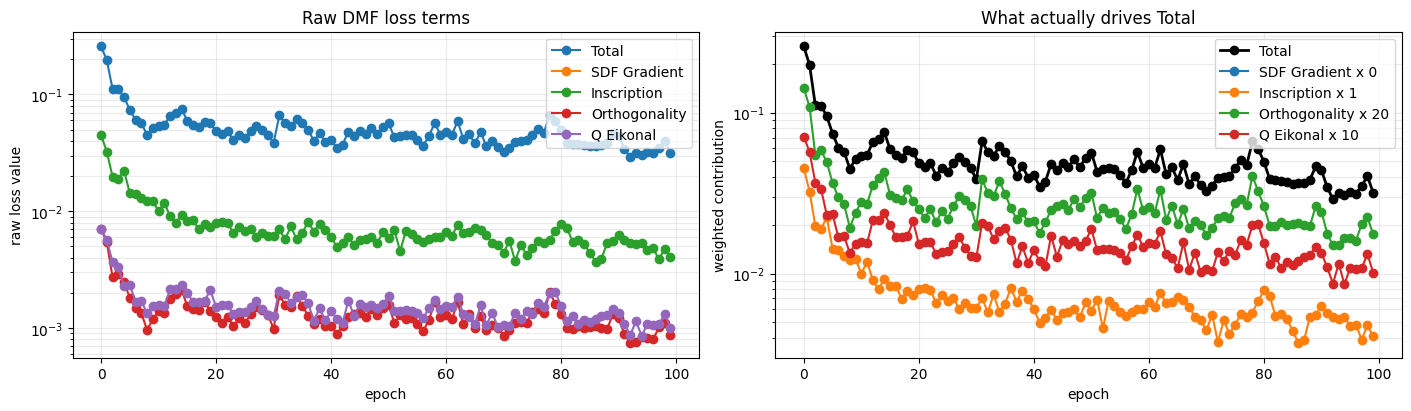

Raw loss first -> last summary:
  Total         : 0.257333 -> 0.0316945  ratio=0.123  (down)
  SDF Gradient  : 0 -> 0  ratio=nan  (up/flat)
  Inscription   : 0.0449984 -> 0.00406844  ratio=0.0904  (down)
  Orthogonality : 0.00707539 -> 0.000875522  ratio=0.124  (down)
  Q Eikonal     : 0.00708269 -> 0.00101156  ratio=0.143  (down)
Weighted contribution first -> last summary:
  Total         : 0.257333 -> 0.0316945  ratio=0.123  (down)
  SDF Gradient  : 0 -> 0  ratio=nan  (up/flat)
  Inscription   : 0.0449984 -> 0.00406844  ratio=0.0904  (down)
  Orthogonality : 0.141508 -> 0.0175104  ratio=0.124  (down)
  Q Eikonal     : 0.0708269 -> 0.0101156  ratio=0.143  (down)


In [11]:
loss_keys = ['Total', 'SDF Gradient', 'Inscription', 'Orthogonality', 'Q Eikonal']
if not USE_GT_SDF:
    loss_keys += ['Eikonal', 'Surface Regularizer']
loss_weight_lookup = {
    'SDF Gradient': LOSS_WEIGHTS.get('sdf_gradient', 0.0),
    'Maximality': LOSS_WEIGHTS.get('maximality', 0.0),
    'Inscription': LOSS_WEIGHTS.get('inscription', 0.0),
    'Orthogonality': LOSS_WEIGHTS.get('orthogonality', 0.0),
    'Q Eikonal': LOSS_WEIGHTS.get('q_eikonal', 0.0),
    'Eikonal': LOSS_WEIGHTS.get('eikonal', 0.0),
    'Surface Regularizer': LOSS_WEIGHTS.get('surface_reg', 0.0),
}
weighted_loss_keys = [k for k in loss_keys if k != 'Total']
weighted_history = {
    k: (np.asarray(history[k], dtype=np.float64) * loss_weight_lookup[k]).tolist()
    for k in weighted_loss_keys
    if k in history
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
ax = axes[0]
for k in loss_keys:
    vals = np.asarray(history[k], dtype=np.float64)
    vals = np.where(vals > 0.0, vals, np.nan)
    ax.plot(vals, marker='o', label=k)
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.set_ylabel('raw loss value')
ax.legend()
ax.set_title('Raw DMF loss terms')
ax.grid(True, which='both', alpha=0.25)

ax = axes[1]
total_vals = np.asarray(history['Total'], dtype=np.float64)
total_vals = np.where(total_vals > 0.0, total_vals, np.nan)
ax.plot(total_vals, marker='o', color='black', linewidth=2.0, label='Total')
for k, vals in weighted_history.items():
    vals = np.asarray(vals, dtype=np.float64)
    vals = np.where(vals > 0.0, vals, np.nan)
    ax.plot(vals, marker='o', label=f'{k} x {loss_weight_lookup[k]:g}')
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.set_ylabel('weighted contribution')
ax.legend()
ax.set_title('What actually drives Total')
ax.grid(True, which='both', alpha=0.25)
plt.show()

print('Raw loss first -> last summary:')
for k in loss_keys:
    vals = np.asarray(history[k], dtype=np.float64)
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        print(f'  {k:14s}: no finite values')
        continue
    first, last = finite[0], finite[-1]
    ratio = last / first if first != 0.0 else np.nan
    direction = 'down' if last < first else 'up/flat'
    print(f'  {k:14s}: {first:.6g} -> {last:.6g}  ratio={ratio:.3g}  ({direction})')

print('Weighted contribution first -> last summary:')
weighted_summary = {'Total': history['Total'], **weighted_history}
for k, vals in weighted_summary.items():
    vals = np.asarray(vals, dtype=np.float64)
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        print(f'  {k:14s}: no finite values')
        continue
    first, last = finite[0], finite[-1]
    ratio = last / first if first != 0.0 else np.nan
    direction = 'down' if last < first else 'up/flat'
    print(f'  {k:14s}: {first:.6g} -> {last:.6g}  ratio={ratio:.3g}  ({direction})')


## Medial Point Clouds


## Field Slice Visualization and Snapshot


Evaluating 4,096 points (64x64) on z=0.0000 slice
Q slice stats min/p05/p50/p95/max: [0.38472012 0.46549841 0.54285508 0.79752886 0.96937776]
MF slice stats min/p05/p50/p95/max: [0.47499695 0.58636363 0.70095763 0.90258676 1.08251476]
SDF color vmax: 0.306667; MF color range: [0, 0.956383]; MF values clipped at SDF vmax: 100.0%
GT medial-axis points: 26,320


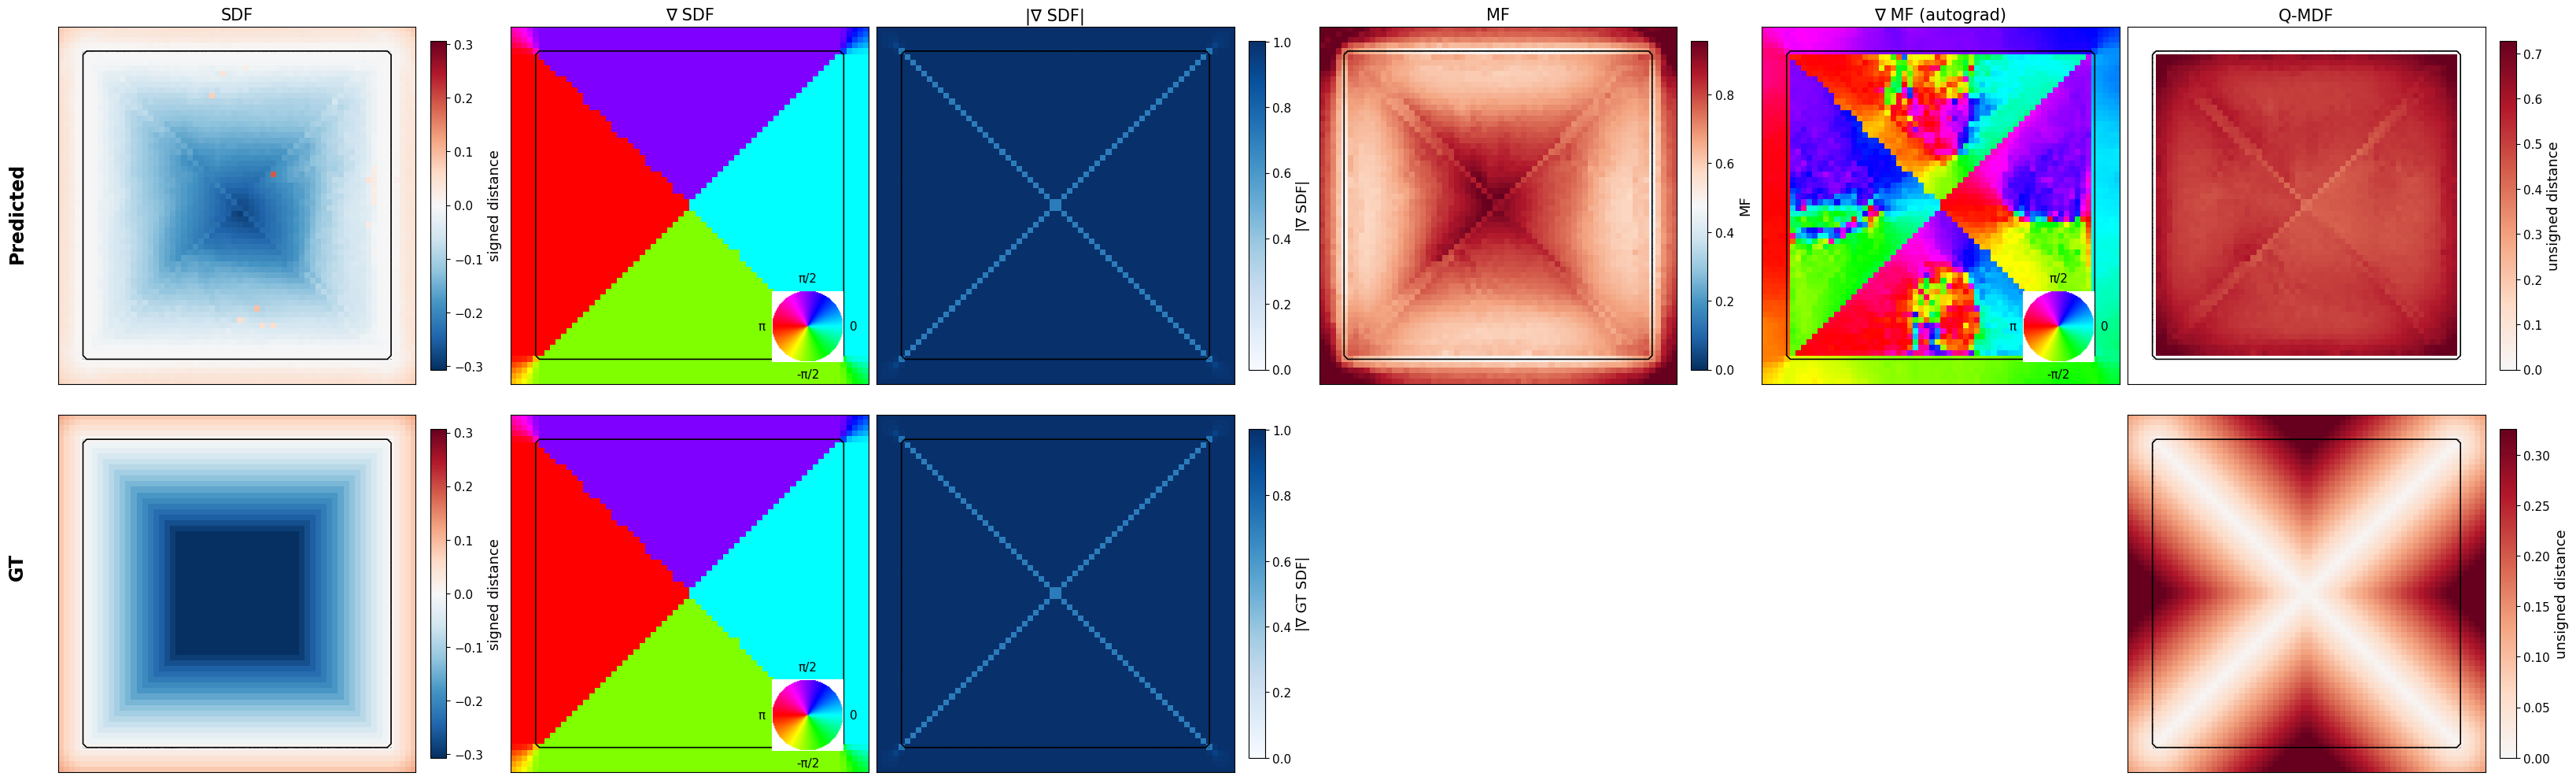

Saved /home/martin/Desktop/points2surf/models/box_q_mdf_features/box_sdf_medial_q_mdf_field_slices.png
Saved timestamped training snapshot: /home/martin/Desktop/points2surf/models/box_q_mdf_features/snapshots/box_20260630_011300


In [12]:
def make_field_slice_queries(pts, axis='z', value=None, grid_res=96, padding=0.08):
    axis_to_dim = {'x': 0, 'y': 1, 'z': 2}
    dim = axis_to_dim[axis]
    axes = [i for i in range(3) if i != dim]

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    span = maxs - mins
    lo = mins[axes] - padding * span[axes]
    hi = maxs[axes] + padding * span[axes]
    value = float(0.5 * (mins[dim] + maxs[dim]) if value is None else value)

    a = np.linspace(lo[0], hi[0], grid_res, dtype=np.float32)
    b = np.linspace(lo[1], hi[1], grid_res, dtype=np.float32)
    aa, bb = np.meshgrid(a, b, indexing='xy')
    queries = np.zeros((grid_res * grid_res, 3), dtype=np.float32)
    queries[:, axes[0]] = aa.reshape(-1)
    queries[:, axes[1]] = bb.reshape(-1)
    queries[:, dim] = value
    extent = [float(a.min()), float(a.max()), float(b.min()), float(b.max())]
    return queries, axes, dim, value, extent


FIG_TITLE_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 15
ROW_LABEL_FONTSIZE = 17
CBAR_LABEL_FONTSIZE = 13
CBAR_TICK_FONTSIZE = 11


def clean_panel_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')


def add_slice_panel(fig, ax, field, title, axes, dim, value, extent,
                    cmap='viridis', vmin=None, vmax=None, cbar_label='field',
                    draw_zero_contour=False, contour_levels=None, contour_color='black',
                    contour_field=None, zero_contour_field=None):
    if hasattr(cmap, 'copy'):
        cmap = cmap.copy()
        cmap.set_bad(color=(1.0, 1.0, 1.0, 0.0))
    im = ax.imshow(np.ma.masked_invalid(field), origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    ny, nx = field.shape
    xs = np.linspace(extent[0], extent[1], nx)
    ys = np.linspace(extent[2], extent[3], ny)
    if draw_zero_contour:
        zero_source = field if zero_contour_field is None else zero_contour_field
        finite_zero = zero_source[np.isfinite(zero_source)]
        if finite_zero.size and finite_zero.min() <= 0.0 <= finite_zero.max():
            ax.contour(xs, ys, zero_source, levels=[0.0], colors='black', linewidths=1.2)
    if contour_levels is not None:
        contour_source = field if contour_field is None else contour_field
        finite = contour_source[np.isfinite(contour_source)]
        if finite.size:
            valid_levels = [level for level in contour_levels if finite.min() <= level <= finite.max()]
            if valid_levels:
                ax.contour(xs, ys, contour_source, levels=valid_levels, colors=contour_color, linewidths=1.2)
    thickness = max((pts[:, dim].max() - pts[:, dim].min()) / SLICE_GRID_RES * 1.5, 1e-4)
    slice_mask = np.abs(pts[:, dim] - value) <= thickness
    if np.any(slice_mask):
        ax.scatter(pts[slice_mask, axes[0]], pts[slice_mask, axes[1]], s=0.25, c='black', alpha=0.3, linewidths=0)
    ax.set_aspect('equal')
    clean_panel_axis(ax)
    ax.set_title(title, fontsize=PANEL_TITLE_FONTSIZE)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=CBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)
    return im


def plot_medial_axis_slice_panel(fig, ax, medial_pts, medial_radii, title, axes, dim, value, extent, cell_size):
    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    clean_panel_axis(ax)
    ax.set_title(title, fontsize=PANEL_TITLE_FONTSIZE)
    thickness = max(GT_MEDIAL_AXIS_SLICE_WIDTH_CELLS * cell_size, 1e-4)
    surface_mask = np.abs(pts[:, dim] - value) <= thickness
    if np.any(surface_mask):
        ax.scatter(pts[surface_mask, axes[0]], pts[surface_mask, axes[1]], s=0.25, c='0.75', alpha=0.35, linewidths=0)
    if medial_pts.shape[0] == 0:
        ax.text(0.5, 0.5, 'no GT medial-axis points', ha='center', va='center', transform=ax.transAxes)
        return None
    slab_mask = np.abs(medial_pts[:, dim] - value) <= thickness
    if not np.any(slab_mask):
        ax.text(0.5, 0.5, 'no GT medial-axis points in slice slab', ha='center', va='center', transform=ax.transAxes)
        return None
    sc = ax.scatter(
        medial_pts[slab_mask, axes[0]], medial_pts[slab_mask, axes[1]],
        c=medial_radii[slab_mask], cmap='plasma', s=7, alpha=0.95, linewidths=0)
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('GT medial radius', fontsize=CBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)
    return sc


def plot_gradient_slice_panel(fig, ax, grad, sdf_field, title, axes, extent, grid_res):
    grad = grad.reshape(grid_res, grid_res, 3)
    u = grad[..., axes[0]]
    v = grad[..., axes[1]]
    angle = np.arctan2(v, u)
    hue = (angle + np.pi) / (2.0 * np.pi)
    hsv = np.stack([hue, np.ones_like(hue), np.ones_like(hue)], axis=-1)
    rgb = plt.matplotlib.colors.hsv_to_rgb(hsv)
    ax.imshow(rgb, origin='lower', extent=extent)
    wheel_res = 80
    wx = np.linspace(-1.0, 1.0, wheel_res)
    wy = np.linspace(-1.0, 1.0, wheel_res)
    wxx, wyy = np.meshgrid(wx, wy, indexing='xy')
    wr = np.sqrt(wxx ** 2 + wyy ** 2)
    wangle = np.arctan2(wyy, wxx)
    whue = (wangle + np.pi) / (2.0 * np.pi)
    wheel_rgb = plt.matplotlib.colors.hsv_to_rgb(
        np.stack([whue, np.ones_like(whue), np.ones_like(whue)], axis=-1))
    wheel_rgba = np.dstack([wheel_rgb, (wr <= 1.0).astype(np.float32)])
    wheel_ax = ax.inset_axes([0.73, 0.06, 0.20, 0.20])
    wheel_ax.imshow(wheel_rgba, origin='lower', extent=(-1.0, 1.0, -1.0, 1.0))
    wheel_ax.set_aspect('equal')
    wheel_ax.text(1.18, 0.0, '0', ha='left', va='center', fontsize=CBAR_TICK_FONTSIZE)
    wheel_ax.text(0.0, 1.18, 'π/2', ha='center', va='bottom', fontsize=CBAR_TICK_FONTSIZE)
    wheel_ax.text(-1.18, 0.0, 'π', ha='right', va='center', fontsize=CBAR_TICK_FONTSIZE)
    wheel_ax.text(0.0, -1.18, '-π/2', ha='center', va='top', fontsize=CBAR_TICK_FONTSIZE)
    clean_panel_axis(wheel_ax)
    for spine in wheel_ax.spines.values():
        spine.set_visible(False)
    xs = np.linspace(extent[0], extent[1], grid_res)
    ys = np.linspace(extent[2], extent[3], grid_res)
    if np.nanmin(sdf_field) <= 0.0 <= np.nanmax(sdf_field):
        ax.contour(xs, ys, sdf_field, levels=[0.0], colors='black', linewidths=1.2)
    ax.set_aspect('equal')
    clean_panel_axis(ax)
    ax.set_title(title, fontsize=PANEL_TITLE_FONTSIZE)
    return rgb


q_mdf_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    'q_mdf_positive_rd_bu_r', plt.get_cmap('RdBu_r')(np.linspace(0.5, 1.0, 256)))

field_slice_grid_res = VIS_SLICE_GRID_RES
slice_queries, slice_axes, slice_dim, slice_value, slice_extent = make_field_slice_queries(
    pts, axis='z', value=None, grid_res=field_slice_grid_res)
slice_cell_size = max(
    (slice_extent[1] - slice_extent[0]) / max(field_slice_grid_res - 1, 1),
    (slice_extent[3] - slice_extent[2]) / max(field_slice_grid_res - 1, 1))
print(f'Evaluating {slice_queries.shape[0]:,} points ({field_slice_grid_res}x{field_slice_grid_res}) on z={slice_value:.4f} slice')

# Always show the frozen backbone SDF prediction here, even when training losses use GT SDF.
slice_phi_pred, slice_q_pred = medial_field.predict_fields_on_queries(
    model, train_opt, slice_queries, pts, device, batch_size=INFER_BATCH)
# trimesh uses positive-inside; flip so GT matches our inside-negative SDF convention.
slice_phi_gt = sample_gt_sdf(slice_queries)
slice_phi_for_medial = slice_phi_gt if USE_GT_SDF else slice_phi_pred
slice_medial = slice_q_pred + np.abs(slice_phi_for_medial)
_, slice_sdf_grad_gt_t = gt_sdf_sampler_torch(
    torch.from_numpy(slice_queries).to(device=device, dtype=torch.float32))
slice_sdf_grad_gt = slice_sdf_grad_gt_t.detach().cpu().numpy().astype(np.float32)
if USE_GT_SDF:
    slice_sdf_grad_pred = slice_sdf_grad_gt
elif USE_SDF_GRADIENT_HEAD and hasattr(model, 'sdf_gradient_head'):
    slice_sdf_grad_pred = medial_field.predict_sdf_gradient_on_queries(
        model, train_opt, slice_queries, pts, device, batch_size=INFER_BATCH)
else:
    slice_sdf_grad_pred = np.zeros_like(slice_queries, dtype=np.float32)
slice_mf_grad, _ = medial_field.predict_medial_gradient_on_queries(
    model, train_opt, slice_queries, pts, device, batch_size=INFER_BATCH,
    mesh_gt_sdf=mesh_gt if USE_GT_SDF and not USE_ANALYTIC_BOX_SDF else None,
    sdf_sampler=gt_sdf_sampler_torch if USE_ANALYTIC_BOX_SDF else None)
sdf_slice = slice_phi_pred.reshape(field_slice_grid_res, field_slice_grid_res)
sdf_gt_slice = slice_phi_gt.reshape(field_slice_grid_res, field_slice_grid_res)
sdf_grad_norm_pred_slice = np.linalg.norm(
    slice_sdf_grad_pred.reshape(field_slice_grid_res, field_slice_grid_res, 3), axis=-1)
sdf_gt_grad_b, sdf_gt_grad_a = np.gradient(
    sdf_gt_slice,
    (slice_extent[3] - slice_extent[2]) / max(field_slice_grid_res - 1, 1),
    (slice_extent[1] - slice_extent[0]) / max(field_slice_grid_res - 1, 1),
    edge_order=2)
sdf_grad_norm_gt_slice = np.sqrt(sdf_gt_grad_a ** 2 + sdf_gt_grad_b ** 2)
if USE_GT_SDF:
    sdf_grad_norm_pred_slice = sdf_grad_norm_gt_slice
q_slice_pred = slice_q_pred.reshape(field_slice_grid_res, field_slice_grid_res)
medial_slice = slice_medial.reshape(field_slice_grid_res, field_slice_grid_res)
inside_slice_mask = sdf_gt_slice < 0.0

# Because the head predicts Q directly, the predicted Q-MDF field is the head output.
q_mdf_source = 'GT SDF' if USE_GT_SDF else 'predicted SDF'
contour_sdf_slice = sdf_gt_slice if USE_GT_SDF else sdf_slice
q_mdf_residual_slice = medial_field.medial_level_score(slice_phi_for_medial, slice_medial).reshape(field_slice_grid_res, field_slice_grid_res)
q_mdf_slice_inside = np.where(inside_slice_mask, q_slice_pred, np.nan)
q_mdf_residual_slice_inside = np.where(inside_slice_mask, q_mdf_residual_slice, np.nan)

sdf_abs = np.abs(np.concatenate([
    sdf_slice[np.isfinite(sdf_slice)],
    sdf_gt_slice[np.isfinite(sdf_gt_slice)],
]))
sdf_vmax = float(np.percentile(sdf_abs, 95)) if sdf_abs.size else 1.0
sdf_vmax = max(sdf_vmax, 1e-6)

medial_vals = medial_slice[np.isfinite(medial_slice)]
medial_vmax = float(np.percentile(medial_vals, 98)) if medial_vals.size else 1.0
medial_vmax = max(medial_vmax, 1e-6)
mf_vis_vmin = -sdf_vmax if USE_SDF_SCALE_FOR_MF_VIS else 0.0
mf_vis_vmax = sdf_vmax if USE_SDF_SCALE_FOR_MF_VIS else medial_vmax
q_debug_vals = q_slice_pred[np.isfinite(q_slice_pred)]
mf_clip_pct = 100.0 * float(np.mean(medial_vals >= sdf_vmax)) if medial_vals.size else 0.0
if q_debug_vals.size:
    print('Q slice stats min/p05/p50/p95/max:', np.nanpercentile(q_debug_vals, [0, 5, 50, 95, 100]))
if medial_vals.size:
    print('MF slice stats min/p05/p50/p95/max:', np.nanpercentile(medial_vals, [0, 5, 50, 95, 100]))
print(f'SDF color vmax: {sdf_vmax:.6g}; MF color range: [{mf_vis_vmin:.6g}, {mf_vis_vmax:.6g}]; MF values clipped at SDF vmax: {mf_clip_pct:.1f}%')

q_vals = q_mdf_slice_inside[np.isfinite(q_mdf_slice_inside)]
q_vmax = float(np.percentile(q_vals, 99)) if q_vals.size else 1.0
q_vmax = max(q_vmax, 1e-6)

sdf_grad_norm_vals = np.concatenate([
    sdf_grad_norm_pred_slice[np.isfinite(sdf_grad_norm_pred_slice)],
    sdf_grad_norm_gt_slice[np.isfinite(sdf_grad_norm_gt_slice)],
])
sdf_grad_norm_vmax = float(np.percentile(sdf_grad_norm_vals, 99)) if sdf_grad_norm_vals.size else 1.0
sdf_grad_norm_vmax = max(sdf_grad_norm_vmax, 1e-6)

if 'gt_medial_axis_pts' not in globals() or 'gt_medial_axis_radii' not in globals():
    if SHAPE_NAME == 'box':
        print('Computing sampled analytic GT medial-axis approximation for box...')
        gt_medial_axis_pts, gt_medial_axis_radii = medial_field.approximate_box_medial_axis_from_bounds(
            mesh_gt.bounds, grid_resolution=max(32, field_slice_grid_res),
            max_points=MAX_MEDIAL_POINTS, seed=123)
        point_cloud.write_ply(str(OUT_DIR / 'gt_medial_axis_box.ply'), gt_medial_axis_pts)
    else:
        print('Computing Voronoi GT medial-axis approximation...')
        gt_medial_axis_pts, gt_medial_axis_radii = medial_field.approximate_medial_axis_voronoi_from_mesh(
            mesh_gt, surface_sample_count=GT_MEDIAL_AXIS_SURFACE_SAMPLES,
            max_points=MAX_MEDIAL_POINTS, seed=123)
        point_cloud.write_ply(str(OUT_DIR / 'gt_medial_axis_voronoi.ply'), gt_medial_axis_pts)
print(f'GT medial-axis points: {gt_medial_axis_pts.shape[0]:,}')
if gt_medial_axis_pts.shape[0] > 0:
    import scipy.spatial as spatial
    gt_axis_tree = spatial.cKDTree(gt_medial_axis_pts)
    gt_axis_udf = gt_axis_tree.query(slice_queries)[0].astype(np.float32)
    gt_axis_udf_slice = gt_axis_udf.reshape(field_slice_grid_res, field_slice_grid_res)
else:
    gt_axis_udf_slice = np.full((field_slice_grid_res, field_slice_grid_res), np.nan, dtype=np.float32)
gt_axis_udf_vals = gt_axis_udf_slice[np.isfinite(gt_axis_udf_slice)]
gt_axis_udf_vmax = float(np.percentile(gt_axis_udf_vals, 95)) if gt_axis_udf_vals.size else q_vmax
gt_axis_udf_vmax = max(gt_axis_udf_vmax, 1e-6)
q_mdf_vmax = q_vmax

fig, axes = plt.subplot_mosaic(
    [['sdf_pred', 'grad_pred', 'grad_norm_pred', 'medial_pred', 'mf_grad_pred', 'q_pred'],
     ['sdf_gt', 'grad_gt', 'grad_norm_gt', '.', '.', 'gt_axis_udf']],
    figsize=(32, 10.0), constrained_layout=True)
add_slice_panel(
    fig, axes['sdf_pred'], sdf_slice, 'SDF', slice_axes, slice_dim, slice_value, slice_extent,
    cmap='RdBu_r', vmin=-sdf_vmax, vmax=sdf_vmax, cbar_label='signed distance',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
add_slice_panel(
    fig, axes['sdf_gt'], sdf_gt_slice, '', slice_axes, slice_dim, slice_value, slice_extent,
    cmap='RdBu_r', vmin=-sdf_vmax, vmax=sdf_vmax, cbar_label='signed distance',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
add_slice_panel(
    fig, axes['medial_pred'], medial_slice, 'MF', slice_axes, slice_dim, slice_value, slice_extent,
    cmap='RdBu_r', vmin=mf_vis_vmin, vmax=mf_vis_vmax, cbar_label='MF',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
plot_gradient_slice_panel(
    fig, axes['mf_grad_pred'], slice_mf_grad, contour_sdf_slice, '∇ MF (autograd)',
    slice_axes, slice_extent, field_slice_grid_res)
add_slice_panel(
    fig, axes['q_pred'], q_mdf_slice_inside, f'Q-MDF', slice_axes, slice_dim, slice_value, slice_extent,
    cmap=q_mdf_cmap, vmin=0.0, vmax=q_mdf_vmax, cbar_label='unsigned distance',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
add_slice_panel(
    fig, axes['gt_axis_udf'], gt_axis_udf_slice, '',
    slice_axes, slice_dim, slice_value, slice_extent,
    cmap=q_mdf_cmap, vmin=0.0, vmax=gt_axis_udf_vmax, cbar_label='unsigned distance',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
plot_gradient_slice_panel(
    fig, axes['grad_pred'], slice_sdf_grad_pred, contour_sdf_slice, '∇ SDF',
    slice_axes, slice_extent, field_slice_grid_res)
plot_gradient_slice_panel(
    fig, axes['grad_gt'], slice_sdf_grad_gt, contour_sdf_slice, '',
    slice_axes, slice_extent, field_slice_grid_res)
add_slice_panel(
    fig, axes['grad_norm_pred'], sdf_grad_norm_pred_slice, '|∇ SDF|',
    slice_axes, slice_dim, slice_value, slice_extent,
    cmap='Blues', vmin=0.0, vmax=sdf_grad_norm_vmax, cbar_label='|∇ SDF|',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
add_slice_panel(
    fig, axes['grad_norm_gt'], sdf_grad_norm_gt_slice, '',
    slice_axes, slice_dim, slice_value, slice_extent,
    cmap='Blues', vmin=0.0, vmax=sdf_grad_norm_vmax, cbar_label='|∇ GT SDF|',
    draw_zero_contour=True, zero_contour_field=contour_sdf_slice)
fig.text(-0.015, 0.73, 'Predicted', rotation=90, va='center', ha='center', fontsize=ROW_LABEL_FONTSIZE, fontweight='bold')
fig.text(-0.015, 0.28, 'GT', rotation=90, va='center', ha='center', fontsize=ROW_LABEL_FONTSIZE, fontweight='bold')
combined_slice_plot = OUT_DIR / 'box_sdf_medial_q_mdf_field_slices.png'
fig.savefig(combined_slice_plot, dpi=180, bbox_inches='tight')
plt.show()
print('Saved', combined_slice_plot)

# Automatic timestamped training snapshot
snapshot_timestamp = time.strftime('%Y%m%d_%H%M%S')
snapshot_dir = OUT_DIR / 'snapshots' / f'{SHAPE_NAME}_{snapshot_timestamp}'
snapshot_dir.mkdir(parents=True, exist_ok=False)

# Save the exact model currently used by the downstream visualizations. Depending
# on the visualization flags, this may be the best orthogonality or GT-axis head.
torch.save(medial_field.q_mdf_head_state_dict(model), snapshot_dir / 'q_mdf_head_current.pth')
if USE_SDF_GRADIENT_HEAD and hasattr(model, 'sdf_gradient_head'):
    torch.save(model.sdf_gradient_head.state_dict(), snapshot_dir / 'sdf_gradient_head_current.pth')
torch.save(model.state_dict(), snapshot_dir / 'points_to_surf_medial_model_state_dict.pth')

snapshot_manifest = {
    'snapshot_timestamp': snapshot_timestamp,
    'shape_name': SHAPE_NAME,
    'shape_obj': str(SHAPE_OBJ),
    'source_out_dir': str(OUT_DIR),
    'use_gt_sdf': USE_GT_SDF,
    'use_analytic_box_sdf': USE_ANALYTIC_BOX_SDF,
    'sdf_gradient_min_face_gap': SDF_GRADIENT_MIN_FACE_GAP,
    'resample_gt_queries_every_batch': RESAMPLE_GT_QUERIES_EVERY_BATCH,
    'gt_query_resample_candidate_mult': GT_QUERY_RESAMPLE_CANDIDATE_MULT,
    'use_query_coords_for_medial': USE_QUERY_COORDS_FOR_MEDIAL,
    'medial_hidden_mult': MEDIAL_HIDDEN_MULT,
    'detach_backbone_for_q_grad': DETACH_BACKBONE_FOR_Q_GRAD,
    'use_query_residual_q_head': USE_QUERY_RESIDUAL_Q_HEAD,
    'query_residual_encoding': QUERY_RESIDUAL_ENCODING,
    'query_fourier_num_freqs': QUERY_FOURIER_NUM_FREQS,
    'orthogonality_warmstart_metric_every': ORTHOGONALITY_WARMSTART_METRIC_EVERY,
    'orthogonality_refine_lbfgs_steps': ORTHOGONALITY_REFINE_LBFGS_STEPS,
    'orthogonality_refine_lbfgs_lr': ORTHOGONALITY_REFINE_LBFGS_LR,
    'orthogonality_refine_batch_size': ORTHOGONALITY_REFINE_BATCH_SIZE,
    'orthogonality_refine_rounds': ORTHOGONALITY_REFINE_ROUNDS,
    'use_best_orthogonality_head_for_vis': USE_BEST_ORTHOGONALITY_HEAD_FOR_VIS,
    'use_best_gt_axis_field_head_for_vis': USE_BEST_GT_AXIS_FIELD_HEAD_FOR_VIS,
    'predict_q_mdf': PREDICT_Q_MDF,
    'use_sdf_gradient_head': USE_SDF_GRADIENT_HEAD,
    'best_gt_axis_field_epoch': best_gt_axis_field_epoch if 'best_gt_axis_field_epoch' in globals() else None,
    'best_gt_axis_field': best_gt_axis_field if 'best_gt_axis_field' in globals() else None,
    'best_orthogonality_epoch': best_orthogonality_epoch if 'best_orthogonality_epoch' in globals() else None,
    'best_orthogonality': best_orthogonality if 'best_orthogonality' in globals() else None,
    'orthogonality_target_normal_rms': ORTHOGONALITY_TARGET_NORMAL_RMS,
    'lr': LR,
    'nepoch': NEPOCH,
    'loss_weights': LOSS_WEIGHTS,
    'model_file': str(MODEL_FILE),
    'param_file': str(PARAM_FILE),
}
(snapshot_dir / 'snapshot_manifest.json').write_text(json.dumps(snapshot_manifest, indent=2, default=str))

snapshot_artifacts = [
    OUT_DIR / 'q_mdf_head.pth',
    OUT_DIR / 'sdf_gradient_head.pth',
    OUT_DIR / 'best_q_mdf_head_by_orthogonality.pth',
    OUT_DIR / 'best_q_mdf_head_by_gt_axis_field.pth',
    OUT_DIR / 'q_mdf_training_summary.json',
    OUT_DIR / 'medial_axis_metrics_vs_epochs.png',
    OUT_DIR / 'box_sdf_medial_q_mdf_field_slices.png',
    OUT_DIR / 'gt_medial_axis_box.ply',
    OUT_DIR / 'gt_medial_axis_voronoi.ply',
]
for artifact in snapshot_artifacts:
    if artifact.is_file():
        shutil.copyfile(artifact, snapshot_dir / artifact.name)

print('Saved timestamped training snapshot:', snapshot_dir)
